## Import - This notebook is for data analysis and visulization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
pr = "pr1"

In [28]:
 # path of results files
coverTable_benchmark = '../result/{}/{}_cover_benchmark.npy'.format(pr, pr)
# coverTable_benchmark = '../result/cover_0_step20.npy'
coverTable1 = '../result/{}/{}_cover_0_step20.npy'.format(pr, pr)
coverTable2 = '../result/{}/{}_cover_100_step20.npy'.format(pr, pr)
coverTable3 = '../result/{}/{}_cover_300_step20.npy'.format(pr, pr)
coverTable4 = '../result/{}/{}_cover_500_step20.npy'.format(pr, pr)
coverTable5 = '../result/{}/{}_cover_500_step20.npy'.format(pr, pr)
coverTable6 = '../result/{}/{}_cover_500_step20.npy'.format(pr, pr)
lb_list = ['benchmark', '1:0', '1:100', '1:300', '1:500', '1:500', '1:500']
# lb_list = ['benchmark', '1:0', '1:300(20)', '1:500(40)']

In [3]:
# load cover table
cover_ben = np.load(coverTable_benchmark)
cover_1 = np.load(coverTable1)
cover_2 = np.load(coverTable2)
cover_3 = np.load(coverTable3)
cover_4 = np.load(coverTable4)
cover_5 = np.load(coverTable5)
cover_6 = np.load(coverTable6)

### 1. Link Cover Rate

In [4]:
# draw space time table
def drawTimeSpace(table):
    idx  = np.arange(0, 5000, 1)
    linkTime_table = np.sum(table, axis=2)
    del table
    linkTime_cover = np.where(linkTime_table[:, idx]>0, 1, 0)
    figs,axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(18, 1))
    axs[0].imshow(linkTime_table[:, idx], cmap='viridis', interpolation='none')
    axs[1].imshow(linkTime_cover, cmap='viridis', interpolation='none')
    print('cover rate is:', np.sum(linkTime_cover)/linkTime_cover.size)

    return linkTime_cover

cover rate is: 0.08009833333333333


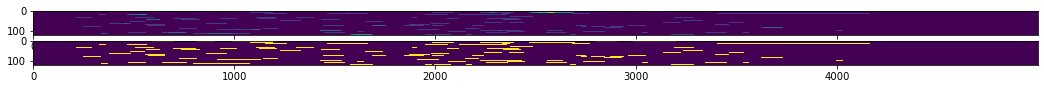

In [5]:
LT_ben = drawTimeSpace(cover_ben)

cover rate is: 0.13401833333333332


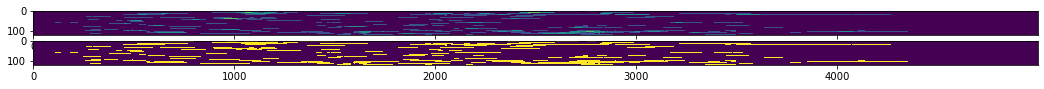

In [6]:
LT_1 = drawTimeSpace(cover_1)

cover rate is: 0.13675166666666666


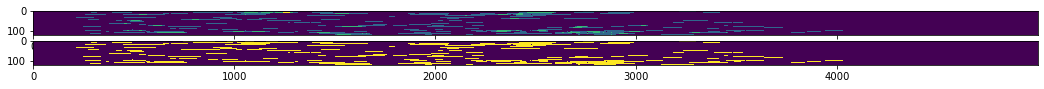

In [7]:
LT_2 = drawTimeSpace(cover_2)

cover rate is: 0.13876333333333332


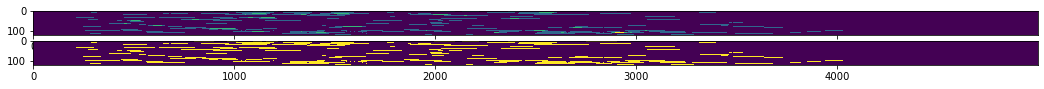

In [8]:
LT_3 = drawTimeSpace(cover_3)

cover rate is: 0.14686333333333335


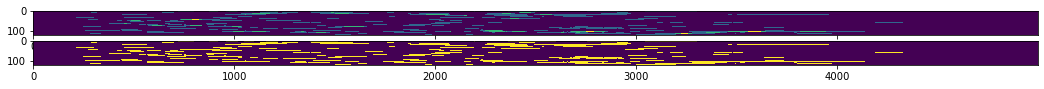

In [9]:
LT_4 = drawTimeSpace(cover_4)

cover rate is: 0.14686333333333335


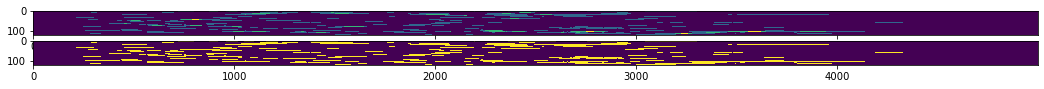

In [10]:
LT_5 = drawTimeSpace(cover_5)

cover rate is: 0.14686333333333335


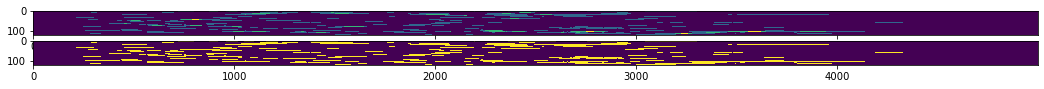

In [11]:
LT_6 = drawTimeSpace(cover_6)

### 2. Vehicle Travel Time

In [12]:
# cover_table = [link, time, veh]
def getTravelTime(table, max_veh_num):
    idx  = np.arange(0, 6000, 1)
    veh_time_table =np.sum(table, axis=0)>0  # [time, veh]
    travel_table = np.sum(veh_time_table, axis=0)
    return travel_table[:max_veh_num]


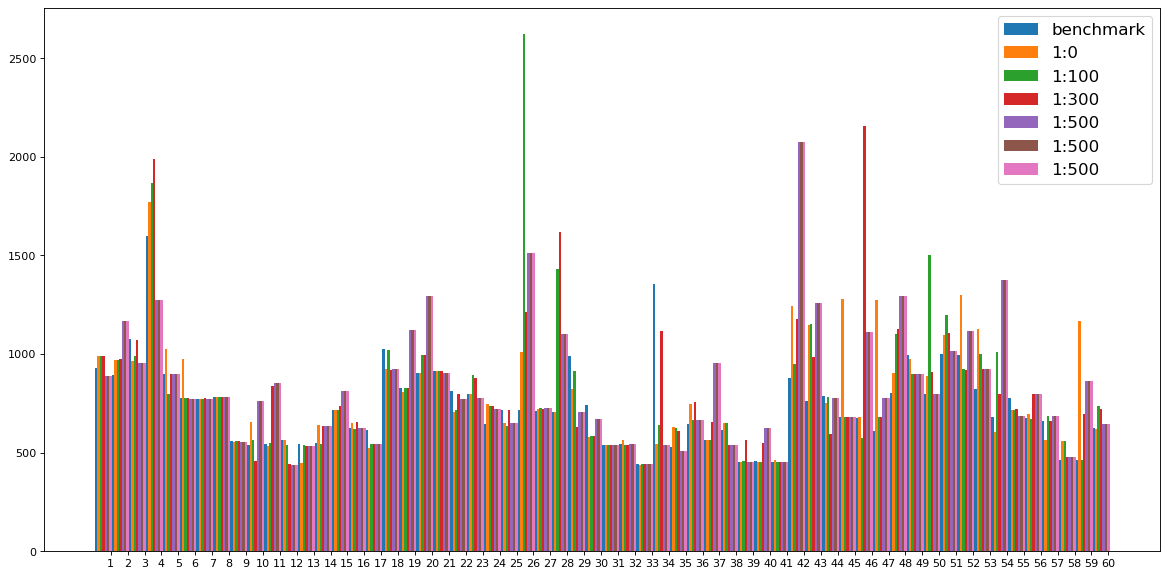

In [30]:
max_veh = 60
travelTime_list = [getTravelTime(cover_ben, max_veh), 
                   getTravelTime(cover_1, max_veh), 
                   getTravelTime(cover_2, max_veh),
                   getTravelTime(cover_3, max_veh),
                   getTravelTime(cover_4, max_veh),
                   getTravelTime(cover_5, max_veh),
                   getTravelTime(cover_6, max_veh),]
veh_list = ['{}'.format(str(i+1)) for i in range(max_veh)]
total_width, n = 1, len(travelTime_list)
width = total_width/n
x = np.arange(len(veh_list))
plt.figure(figsize=(18, 9), dpi=80)

for k in range(len(travelTime_list)):
    xx = x + np.ones(x.shape)*k*width
    plt.bar(xx, travelTime_list[k], width=width, label = str(k), tick_label = veh_list)
plt.legend(lb_list, fontsize=15)
plt.show()

[737.56666667 791.21666667 807.93333333 816.61666667 828.2
 828.2        828.2       ] [0.08009833 0.13401833 0.13675167 0.13876333 0.14686333 0.14686333
 0.14686333]


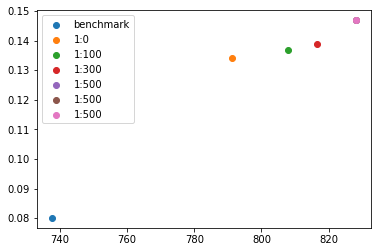

In [29]:
tt_mean = np.mean(np.array(travelTime_list),axis=1)  # travel time
cover_mean = np.array([np.sum(LT_ben)/LT_ben.size,
                       np.sum(LT_1)/LT_1.size,
                       np.sum(LT_2)/LT_2.size, 
                       np.sum(LT_3)/LT_3.size,
                       np.sum(LT_4)/LT_4.size,
                       np.sum(LT_5)/LT_5.size,
                       np.sum(LT_6)/LT_6.size])
# lb_list = ['benchmark', '1:500', '1:1000', '1:1500', '1:2000']
for i in range(tt_mean.shape[0]):
    plt.scatter(tt_mean[i], cover_mean[i], label = lb_list[i])
plt.legend()
print(tt_mean, cover_mean)

### 3. Network Visulize

In [15]:
import networkx as nx
import sumolib

#### 3.1 load network

In [16]:
def getDis(crd1, crd2):
    return np.sqrt((crd1[0] - crd2[0]) ** 2 + (crd1[1] - crd2[1]) ** 2)

In [17]:
def netInit(X, Y, net_file='../src/sumo_cfg/toy_net/toy_net1.net.xml'):
    net = sumolib.net.readNet(net_file)
    G = nx.Graph()
    tmp_node = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    pos = {}
    for x in range(X):
        for y in range(Y):
            node_idx = tmp_node[x]+tmp_node[y]
            pos[node_idx] = net.getNode(node_idx).getCoord()
            G.add_node(node_idx, color='red', pos=net.getNode(node_idx).getCoord())
    
    for x in range(X):
        for y in range(Y):
            if x + 1 < X and y + 1 < Y:
                current = tmp_node[x] + tmp_node[y]
                current_right = tmp_node[x] + tmp_node[y + 1]
                current_down = tmp_node[x + 1] + tmp_node[y]
                dis1 = getDis(net.getNode(current).getCoord(), net.getNode(current_right).getCoord())
                dis2 = getDis(net.getNode(current).getCoord(), net.getNode(current_down).getCoord())
                G.add_weighted_edges_from([(current, current_right, dis1),
                                                    (current, current_down, dis2)])
            elif y + 1 == Y and x + 1 < X:
                current = tmp_node[x] + tmp_node[y]
                current_down = tmp_node[x + 1] + tmp_node[y]
                dis2 = getDis(net.getNode(current).getCoord(), net.getNode(current_down).getCoord())
                G.add_weighted_edges_from([(current, current_down, dis2)])
            elif x + 1 == X and y + 1 < Y:
                current = tmp_node[x] + tmp_node[y]
                current_right = tmp_node[x] + tmp_node[y + 1]
                dis1 = getDis(net.getNode(current).getCoord(), net.getNode(current_right).getCoord())
                G.add_weighted_edges_from([(current, current_right, dis1)])
            elif x == y == X-1:
                break
    return G, pos

In [18]:
G, pos = netInit(6,6)

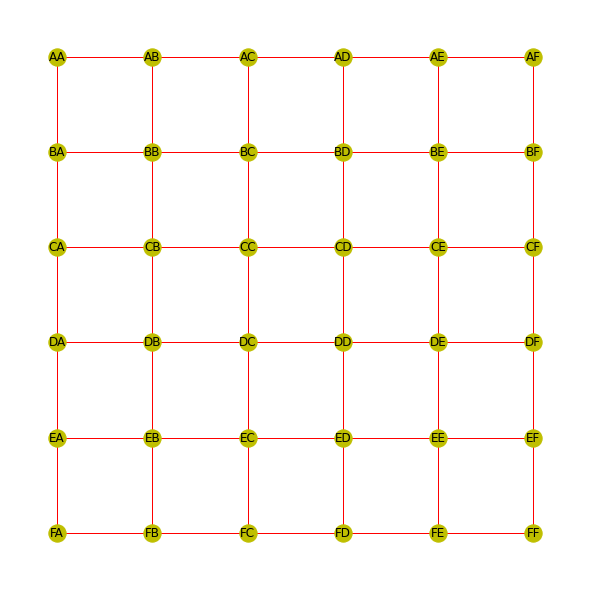

In [19]:
plt.figure(figsize=(8, 8))
edges,weights = zip(*nx.get_edge_attributes(G,'weight').items())

# pos = nx.layout(G)
# print(pos)
# print(edges)
# print(weights)

nx.draw(G, pos, with_labels = True, node_color='y',
        edgelist=edges, edge_color='r', 
        width=1, edge_cmap=plt.cm.Blues)
plt.show()

# nx.draw(H, pos, with_labels = True, node_color='y', 
#         edgelist=edges, edge_color=weights, 
#         width=weights, edge_cmap=plt.cm.Blues)



### 3.2 visulize cover&TT

In [20]:
def drawCoverNet(G, cover_table, net_file='../src/sumo_cfg/toy_net/toy_net1.net.xml'):
    """
    cover_table = [link, time, veh]
    """
    obs_table = np.where(np.sum(cover_table, axis=2)>0, 1, 0)
    link_cover = np.sum(obs_table, axis=1)/obs_table.shape[1]
    net = sumolib.net.readNet(net_file)
#     print(link_cover)
    for i in range(cover_table.shape[0]):
        if i <60: 
            edge_id = 'E'+str(i+1)
        else: 
            edge_id = '-E'+str(i-59)
        
        nextNodeID = net.getEdge(edge_id).getToNode().getID()
        lastNodeID = net.getEdge(edge_id).getFromNode().getID()
        G[lastNodeID][nextNodeID]['weight']=link_cover[i]
    return G
        
            

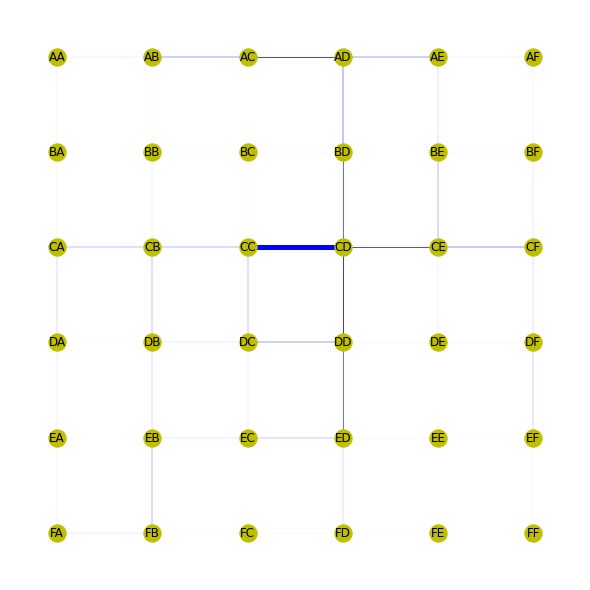

In [21]:
G1 = drawCoverNet(G, cover_ben)

plt.figure(figsize=(8, 8))
    
edges,weights = zip(*nx.get_edge_attributes(G1,'weight').items())

    # pos = nx.layout(G)
    # print(pos)
    # print(edges)
    # print(weights)
    
# normalize weights
weights = weights/max(weights)
weights = np.power(weights, 3)

nx.draw(G1, pos, with_labels = True, node_color='y',
        edgelist=edges, edge_color='b', 
        width=5*weights, edge_cmap=plt.cm.Blues)
plt.show()

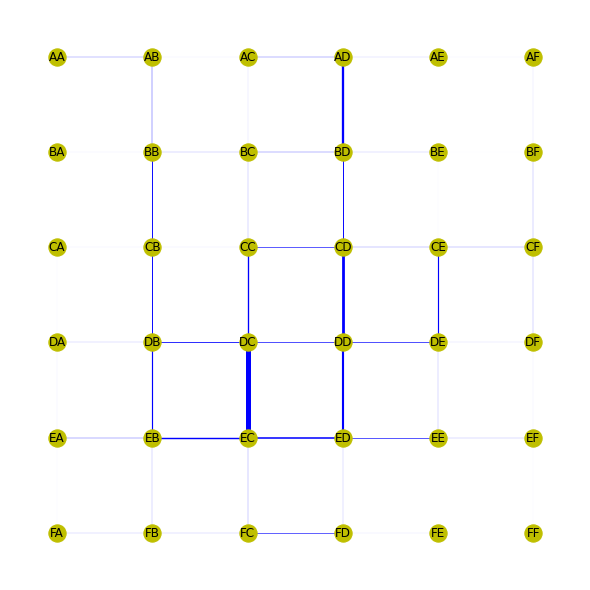

In [22]:
G2 = drawCoverNet(G, cover_1)

plt.figure(figsize=(8, 8))
    
edges,weights = zip(*nx.get_edge_attributes(G2,'weight').items())

    # pos = nx.layout(G)
    # print(pos)
    # print(edges)
    # print(weights)
    
# normalize weights
weights = weights/max(weights)
weights = np.power(weights, 3)

nx.draw(G2, pos, with_labels = True, node_color='y',
        edgelist=edges, edge_color='b', 
        width=5*weights, edge_cmap=plt.cm.Blues)
plt.show()

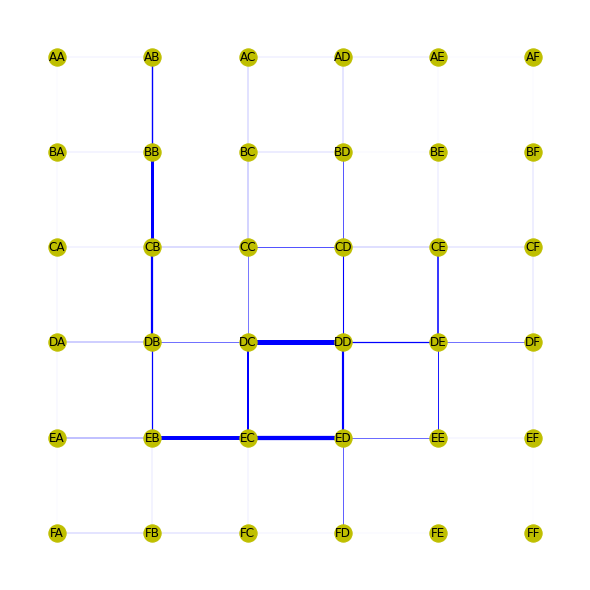

In [23]:
G3 = drawCoverNet(G, cover_2)

plt.figure(figsize=(8, 8))
    
edges,weights = zip(*nx.get_edge_attributes(G3,'weight').items())

    # pos = nx.layout(G)
    # print(pos)
    # print(edges)
    # print(weights)
    
# normalize weights
weights = weights/max(weights)
weights = np.power(weights, 3)

nx.draw(G3, pos, with_labels = True, node_color='y',
        edgelist=edges, edge_color='b', 
        width=5*weights, edge_cmap=plt.cm.Blues)
plt.show()

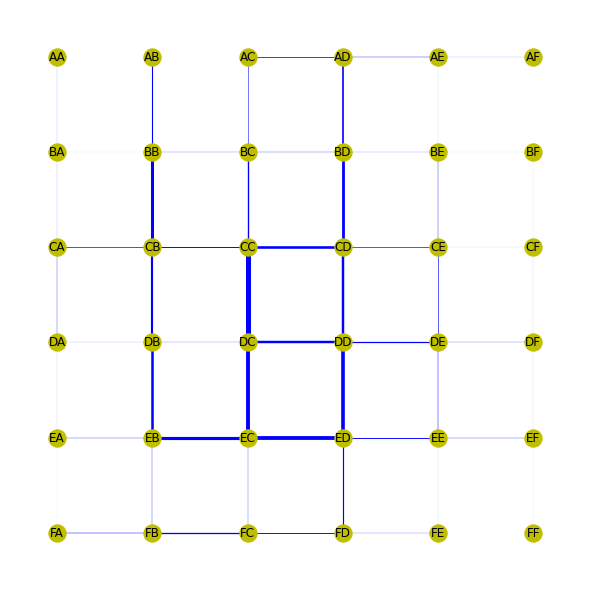

In [24]:
G4 = drawCoverNet(G, cover_3)

plt.figure(figsize=(8, 8))
    
edges,weights = zip(*nx.get_edge_attributes(G4,'weight').items())

    # pos = nx.layout(G)
    # print(pos)
    # print(edges)
    # print(weights)
    
# normalize weights
weights = weights/max(weights)
weights = np.power(weights, 3)

nx.draw(G4, pos, with_labels = True, node_color='y',
        edgelist=edges, edge_color='b', 
        width=5*weights, edge_cmap=plt.cm.Blues)
plt.show()

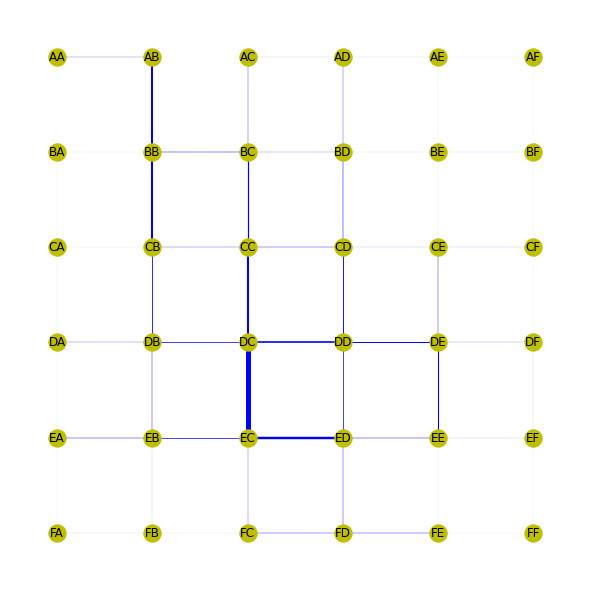

In [25]:
G5 = drawCoverNet(G, cover_4)

plt.figure(figsize=(8, 8))
    
edges,weights = zip(*nx.get_edge_attributes(G5,'weight').items())

    # pos = nx.layout(G)
    # print(pos)
    # print(edges)
    # print(weights)
    
# normalize weights
weights = weights/max(weights)
weights = np.power(weights, 3)

nx.draw(G5, pos, with_labels = True, node_color='y',
        edgelist=edges, edge_color='b', 
        width=5*weights, edge_cmap=plt.cm.Blues)
plt.show()

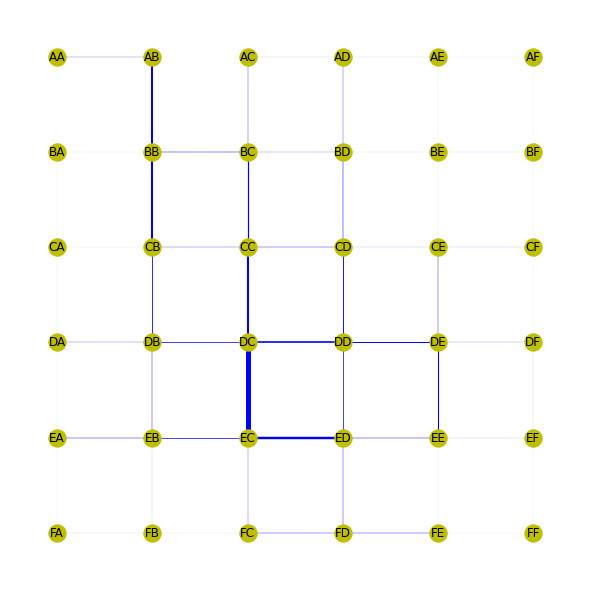

In [26]:
G6 = drawCoverNet(G, cover_5)

plt.figure(figsize=(8, 8))
    
edges,weights = zip(*nx.get_edge_attributes(G6,'weight').items())

    # pos = nx.layout(G)
    # print(pos)
    # print(edges)
    # print(weights)
    
# normalize weights
weights = weights/max(weights)
weights = np.power(weights, 3)

nx.draw(G6, pos, with_labels = True, node_color='y',
        edgelist=edges, edge_color='b', 
        width=5*weights, edge_cmap=plt.cm.Blues)
plt.show()

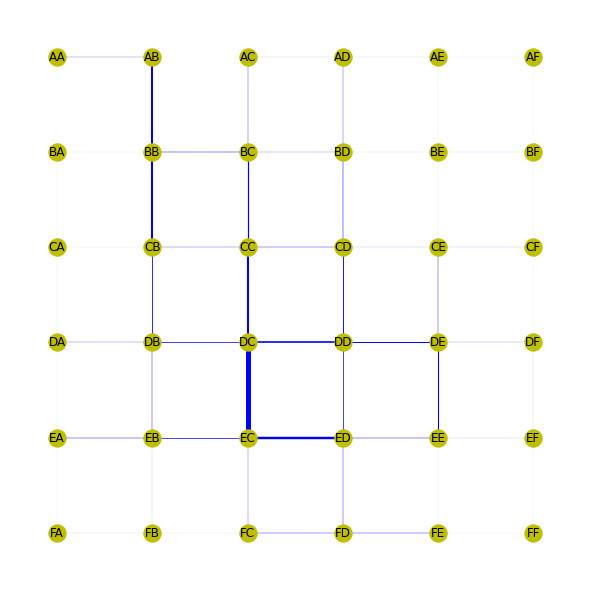

In [27]:
G7 = drawCoverNet(G, cover_6)

plt.figure(figsize=(8, 8))
    
edges,weights = zip(*nx.get_edge_attributes(G7,'weight').items())

    # pos = nx.layout(G)
    # print(pos)
    # print(edges)
    # print(weights)
    
# normalize weights
weights = weights/max(weights)
weights = np.power(weights, 3)

nx.draw(G7, pos, with_labels = True, node_color='y',
        edgelist=edges, edge_color='b', 
        width=5*weights, edge_cmap=plt.cm.Blues)
plt.show()